# Sources of Truth — Reproduction Notebook

Reproduction code for **"Sources of Truth: A Multi-Platform, Multilingual Audit of Citations in AI
Mental Health Information Queries."**

This notebook is self-contained. Running it top to bottom will

1. load the two released data files,
2. rebuild the nine-category source-type classifier,
3. recompute every statistic quoted in the manuscript, and
4. regenerate all five manuscript figures plus one supplementary figure.

## Data files

| File | Rows | Description |
|---|---|---|
| `product_sources_annotated.csv` | 15,929 | One row per citation. The analytic dataset. |
| `product_sources_responses.csv` | 1,140 | One row per AI response, with per-response citation counts. |

Both datasets are available and can be downloaded at https://huggingface.co/datasets/MindBench/search-source-audit

## Requirements

```
python >= 3.10   numpy   pandas   matplotlib   seaborn >= 0.13   squarify
```

`squarify` is needed only for the treemap (Figure 2). Install with `pip install squarify`.

## A note on exact reproducibility

Two figure panels draw bootstrap 95% confidence intervals, which are random by default. Every such
call here passes an explicit `seed=SEED`, so repeated runs are byte-identical. Changing `SEED`
changes the confidence intervals slightly but no reported estimate.

Rendering also depends on the available fonts. The figures ask for Helvetica and fall back to Arial,
then DejaVu Sans. Glyph metrics differ slightly between them, so text may wrap differently on a
machine without Helvetica; the data drawn are unaffected.

## Study design in one paragraph

Twenty English mental health questions were put to three free consumer AI search products (ChatGPT,
Perplexity, Google AI Overview) under two prompt conditions (the question alone and the question
followed by "List your sources."), with each condition administered five times. Three of the twenty
questions were additionally translated into six languages (Spanish, Japanese, Ukrainian, Hindi,
Nepali, Twi). Annotators recorded every externally cited source. Data were collected 25 June – 20
July 2026.

## 1. Environment and settings

In [2]:
import os, re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import seaborn as sns
import squarify

warnings.filterwarnings("ignore")

# Every bootstrap confidence interval in this notebook uses this seed, so the figures are
# byte-identical across runs. Nothing else in the analysis is stochastic.
SEED = 0
np.random.seed(SEED)

FIGDIR = "figures_reproduction"
TABDIR = "analysis_tables_reproduction"   
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

def save(name):
    """Write each figure as both PNG (for the manuscript) and PDF (vector, for typesetting)."""
    plt.savefig(os.path.join(FIGDIR, name + ".png"))
    plt.savefig(os.path.join(FIGDIR, name + ".pdf"))

for m in (np, pd, mpl, sns):
    print(f"{m.__name__:12s} {m.__version__}")
print(f"{'python':12s} {sys.version.split()[0]}")

numpy        2.0.2
pandas       2.3.3
matplotlib   3.9.4
seaborn      0.13.2
python       3.9.6


### Visual style

One shared style for every figure. The nine-category palette is worth a comment: `commercial health`
was split into `nonprofit health system` + `commercial health` during review, which required a ninth
colour. The original eight-slot ramp could not simply be extended — in it the two largest categories
sat at ΔE 5.3 in normal vision and 4.5 under deuteranopia, below the ΔE 15 / 8 floors, meaning they
were not reliably distinguishable in a stacked bar even with full colour vision. The nine below keep
the house vocabulary but are re-stepped so the set validates: worst adjacent ΔE 19.6 in normal
vision, 10.2 under simulated CVD. Grey is reserved for `other` so the residual category reads as a
non-hue. The gold sits just under 3:1 contrast against white, so these figures always carry visible
category labels rather than relying on colour alone.

In [2]:
mpl.rcParams.update({
    "font.family": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 12,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12.5, "axes.labelcolor": "#222", "axes.labelweight": "medium",
    "xtick.labelsize": 11, "ytick.labelsize": 11, "text.color": "#222",
    "xtick.color": "#333", "ytick.color": "#333",
    "axes.edgecolor": "#5a5a5a", "axes.linewidth": 1.0, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#e2e2e2", "grid.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "savefig.dpi": 200, "savefig.bbox": "tight", "legend.frameon": False,
})

GREEN, GREEN_L, TEAL = "#2E8B72", "#84C4A6", "#2C7A8C"
BLUE, BLUE_L, NAVY   = "#3B6FA0", "#93BBDD", "#1F3F5F"
CORAL, GOLD, GREY    = "#C0574B", "#D6A343", "#98A2AA"

PROVIDER_ORDER = ["ChatGPT", "Perplexity", "Google AI Overview"]
PROVIDER_PAL   = {"ChatGPT": "#2E8B72", "Perplexity": "#159AAB", "Google AI Overview": "#2F5E9E"}
VARIANT_ORDER  = ["question only", "question + list sources"]
VARIANT_PAL    = {"question only": BLUE_L, "question + list sources": GREEN}

TYPE_ORDER = ["government/public", "academic/journal", "nonprofit health system",
              "commercial health", "nonprofit/advocacy", "encyclopedia (wiki)",
              "news/media", "social/video", "other"]
TYPE_PAL = {"government/public":       "#3670AC",   # house blue
            "academic/journal":        "#C4622C",   # terracotta
            "nonprofit health system": "#149B7C",   # house green/teal
            "commercial health":       "#C79418",   # house gold
            "nonprofit/advocacy":      "#C86D9C",   # muted rose
            "encyclopedia (wiki)":     "#2A8A2E",   # green
            "news/media":              "#5B47AD",   # muted violet
            "social/video":            "#C64B3C",   # house coral
            "other":                   "#98A2AA"}   # house grey, deliberately a non-hue

LANG7 = ["English", "Spanish", "Japanese", "Ukrainian", "Hindi", "Nepali", "Twi"]
print("style set;", len(TYPE_ORDER), "source-type categories")

style set; 9 source-type categories


## 2. Data

`sources_long_annotated.csv` is the analytic dataset: one row per citation, already carrying the
derived columns (`source_type`, `is_local_source`, `lang_appropriate`, …). Section 3 rebuilds
`source_type` from scratch and checks it against what is stored here.

**English-only scope.** Every analysis except the cross-lingual figure uses English queries only.
The six non-English languages cover just 3 of the 20 questions each, so pooling them with English
would bias any aggregate toward those three questions.

In [ ]:
src  = pd.read_csv("product_sources_annotated.csv", low_memory=False)
resp = pd.read_csv("product_sources_responses.csv", low_memory=False)

src_en  = src[src.language == "en"].copy()
resp_en = resp[resp.language == "en"].copy()

print(f"citations : {len(src):,} rows x {src.shape[1]} cols   ({len(src_en):,} English)")
print(f"responses : {len(resp):,} rows x {resp.shape[1]} cols   ({len(resp_en):,} English)")
print(f"unique registrable domains: {src.domain.nunique():,}")
print(f"\nplatforms : {', '.join(sorted(src.provider_name.unique()))}")
print(f"languages : {', '.join(sorted(src.language_name.unique()))}")
print(f"conditions: {', '.join(sorted(src.variant_label.unique()))}")

def citation_site(host, domain):
    h = str(host).lower()
    if "pubmed" in h or "pmc.ncbi" in h or "ncbi.nlm.nih.gov" in h:
        return "ncbi/pubmed/pmc"
    return domain

for _df in (src, src_en):
    _df["site"] = [citation_site(h, d) for h, d in zip(_df["host"], _df["domain"])]

src.head(3)

citations : 15,929 rows x 30 cols   (10,959 English)
responses : 1,140 rows x 37 cols   (600 English)
unique registrable domains: 1,713

platforms : ChatGPT, Google AI Overview, Perplexity
languages : English, Hindi, Japanese, Nepali, Spanish, Twi, Ukrainian
conditions: question + list sources, question only


,cell_id,volunteer,source_file,provider,provider_name,language,language_name,resource_tier,variant,variant_label,...,lang_appropriate,source_type,type_rule,tld_bucket,is_local_source,section_label,has_utm,utm_chatgpt,is_crisis,site
0,v1|chatgpt|en|med-depression|naked,1,Volunteer 1.docx,chatgpt,ChatGPT,en,English,high,naked,question only,...,False,academic/journal,NLM literature portal (PubMed/PMC/NCBI),US .gov/.mil,False,in-text,True,True,False,ncbi/pubmed/pmc
1,v1|chatgpt|en|med-depression|naked,1,Volunteer 1.docx,chatgpt,ChatGPT,en,English,high,naked,question only,...,False,nonprofit health system,nonprofit health-system list,.org,False,in-text,True,True,False,mayoclinic.org
2,v1|chatgpt|en|med-depression|naked,1,Volunteer 1.docx,chatgpt,ChatGPT,en,English,high,naked,question only,...,False,nonprofit health system,nonprofit health-system list,.org,False,in-text,True,True,False,mayoclinic.org


## 3. The source-type classifier

Citations are classified into nine organizational categories describing **who publishes the source**,
not what it says:

1. **Government / public health** — `.gov` and country-government domains, plus intergovernmental
   (WHO) and national health-service (NHS) sites
2. **Academic / journal** — the biomedical literature (PubMed, PMC, NCBI), universities (`.edu`),
   scholarly publishers and DOIs, and professional clinical compendia
3. **Nonprofit health system** — patient education from nonprofit and university-affiliated hospitals
   and health systems (Mayo Clinic, Cleveland Clinic, …)
4. **Commercial health** — for-profit health publishers and telehealth, pharmaceutical and
   branded-drug sites, private hospital groups
5. **Nonprofit / advocacy** — NGOs and advocacy groups (NAMI, the American Psychiatric Association)
6. **Encyclopedia (wiki)** — Wikipedia and comparable reference wikis
7. **News / media**
8. **Social / video** — social platforms, forums, video (YouTube, Reddit, Facebook)
9. **Other** — residual

### How it works

`classify_type()` is an **ordered rule cascade**, deterministic and containing no learned or
generative component. It reads three fields parsed from each URL with the Public Suffix List: the
**host** (`www.nimh.nih.gov`), the **registrable domain** (`nih.gov`), and the **public suffix**
(`gov`). Rule order matters and encodes real decisions:

- **Host overrides run first**, so `pubmed.ncbi.nlm.nih.gov` classifies as academic rather than being
  swallowed by the `.gov` rule that would otherwise catch everything on `nih.gov`.
- **Curated domain lists run before structural suffix rules**, so an institution like `nimhans.ac.in`
  resolves to its actual institutional role instead of defaulting to the `.ac` academic suffix.
- **Structural public-suffix rules** then catch government, academic and nonprofit suffixes across
  every country, reading the *public suffix* rather than the host — the distinction matters, because
  `"gov.uk".endswith(".gov.uk")` is `False` and testing the host would silently misclassify every
  UK government citation.
- **A name-pattern heuristic** is the last resort before `other`, catching small clinics and private
  practices. Rules tagged `HEURISTIC` are the least certain and are flagged as such in the audit
  table exported below, so any reader can inspect exactly those assignments.

Every assignment records **which rule fired** (`type_rule`), so each of the 15,929 classifications
can be traced to its justification.

### Human validation

Assignments were validated against human coding in two stages. The 100 most-cited domains — 72.1% of
all citations — were reviewed and finalized in full by two authors. A random sample of 200 domains
from the remainder, spread as evenly as possible across the nine categories, was then coded
independently by two annotators. Agreement was high: Cohen's κ = 0.88 between the two reviewers, and
0.89 and 0.86 between each reviewer and the classifier.

In [ ]:
TYPE_ORDER = [
    "government/public", "academic/journal", "nonprofit health system",
    "commercial health", "nonprofit/advocacy", "encyclopedia (wiki)",
    "news/media", "social/video", "other",
]

# ----------------------------------------------------------------------------------
# 1. Social / video / general platforms
# ----------------------------------------------------------------------------------
SOCIAL_VIDEO_HOST = {
    "youtube.com", "youtu.be", "reddit.com", "facebook.com", "instagram.com",
    "twitter.com", "x.com", "tiktok.com", "linkedin.com", "quora.com", "pinterest.com",
    "threads.net", "t.me", "tumblr.com", "spotify.com", "podbean.com", "blogspot.com",
    "slideshare.net", "scribd.com", "studocu.com", "note.com", "medium.com",
    "substack.com", "discord.com", "whatsapp.com", "vk.com", "weebly.com",
    "shazam.com", "vumedi.com", "pressbooks.pub", "meta.com",
}

# ----------------------------------------------------------------------------------
# 2. Encyclopedia / reference wikis
# ----------------------------------------------------------------------------------
ENCYCLOPEDIA = {"wikihow.com", "britannica.com", "merriam-webster.com", "psychdb.com",
                "physio-pedia.com", "rxwiki.com", "traumadissociation.com", "theravive.com",
                "encyclopedia.pub"}

# ----------------------------------------------------------------------------------
# 3. Academic / journal — scholarly publishers, indexes, clinical compendia
# ----------------------------------------------------------------------------------
JOURNAL_DOMAINS = {
    "sciencedirect.com", "springer.com", "link.springer.com", "nature.com", "wiley.com",
    "onlinelibrary.wiley.com", "tandfonline.com", "jamanetwork.com", "thelancet.com", "bmj.com",
    "cambridge.org", "psychiatryonline.org", "doi.org", "researchgate.net", "frontiersin.org",
    "mdpi.com", "plos.org", "journals.plos.org", "sagepub.com", "oup.com", "academic.oup.com",
    "biomedcentral.com", "cochrane.org", "cochranelibrary.com", "semanticscholar.org",
    "psycnet.apa.org", "jstor.org", "dovepress.com", "karger.com", "elsevier.com",
    "elsevierpure.com", "ovid.com", "ebsco.com", "gale.com", "scielo.org", "cureus.com",
    "openpublichealthjournal.com", "medworksmedia.com", "theclinics.com", "srce.hr",
    "canjhealthtechnol.ca", "rivistadipsichiatria.it", "rbppsiquiatria.org.br",
    "scimagojr.com", "lumenlearning.com", "libguides.com", "inflibnet.ac.in",
    "igaku-shoin.co.jp", "kyorin.co.jp", "nikkeibp.co.jp", "empendium.com",
    "msdmanuals.com", "merckmanuals.com", "uptodate.com", "dailymed.nlm.nih.gov", "statpearls.com", "psychscenehub.com", "psychiatrist.com", "dynamed.com",
    "epocrates.com", "mdcalc.com", "novopsych.com", "psychologytools.com", "therapistaid.com",
    "neiglobal.com", "thecarlatreport.com", "mycme.com", "oakstone.com",
    "psychopharmacopeia.com", "medlink.com", "nursingcenter.com", "nursekey.com",
    "pediatriconcall.com", "mims.com", "galinos.gr", "ge-bu.nl", "vidal.fr", "sefap.it",
    "smpdb.ca", "ncats.io", "mednet.ca", "cda-amc.ca", "peptiko.gr",
    "lww.com", "aan.com", "healio.com", "mattioli1885journals.com", "accp.com",
    "guidelinecentral.com", "fpnotebook.com", "lexi.com", "globalrph.com",
    "meded101.com", "medaptly.com", "medsinfo.com.au", "medex.com.bd",
    "nepjol.info", "jnma.com.np", "umj.com.ua", "health-ua.com", "accemedin.com",
    "dnmcps.com.ua", "meduniver.com", "aipc.net.au", "digimedupdates.com",
    "uni-marburg.de", "amsterdamumc.nl", "muni.cz", "usal.es", "uam.es",
    "unirioja.es", "unam.mx", "nihonshinkyu.jp", "brainscience-union.jp",
    "jmedj.co.jp", "alfresa-pharma.co.jp", "secretariat.ne.jp", "c-linkage.co.jp",
    "congre.co.jp", "gpnotebook.com", "chrisaikenmd.com", "psychange.net",
    "centerwatch.com", "mcpap.com", "ahpnetwork.com", "attopgx.com",
    "gonetowar.com", "aapp.plus", "oxcadatresources.com",
    "ndlitsey.com.ua", "oneu.od.ua", "eduhub.in.ua", "otfk.od.ua", "ac.kharkov.ua",
    "hvpku.ks.ua", "bcpto.zp.ua", "naurok.com.ua", "tind.io", "libanswers.com",
    "jpsychopathol.it", "jneurology.com",         
    "mayoclinicproceedings.org", "shanghaiarchivesofpsychiatry.org", "clinpgx.org",
}
# hosts (not registrable domains) that are academic
ACADEMIC_HOSTS = {"scholar.google.com", "books.google.com"}
# literature portals that live on .gov but are academic in function
ACADEMIC_HOST_SUBSTR = ("pubmed", "pmc.ncbi", "ncbi.nlm.nih.gov")

# ----------------------------------------------------------------------------------
# 4. Government / public health
# ----------------------------------------------------------------------------------
GOV_INTL = {"who.int", "un.org", "europa.eu", "paho.org", "au.int", "oecd.org",
            "unicef.org", "unhcr.org", "iarc.who.int", "who.foundation",
            "worldbank.org", "nice.org.uk"}
GOV_DOMAINS = {
    "nhsinform.scot", "nhs.uk", "gov.uk", "parliament.uk", "hse.ie", "hpra.ie",
    "hres.ca", "canada.ca", "alberta.ca", "healthify.nz", "bpac.org.nz",
    "helsenorge.no", "regionostergotland.se", "guiasalud.es", "isciii.es",
    "saludcastillayleon.es", "castillalamancha.es", "comunidad.madrid",
    "ensayosclinicos.es", "minsal.cl", "sansad.in", "esteri.it",
    "veteranscrisisline.net", "govdelivery.com", "fda.report", "ndclist.com",
    "state.or.us", "nhghealth.com.sg", "prostir.ua",
    "healthhub.sg", "nccs.com.sg", "988.ca", "mygov.in", "myflfamilies.com",
    "mapnet.online", "uoz.cn.ua", "iplex.com.ua",
    "kenkou-fukushima.jp", "graffer.jp", "kibousupport2.com", "yorisoi-chat.jp",
    "tokuteikenshin-hokensidou.jp", "georgiacollaborative.com", "kidcentraltn.com",
    "psychiatry.ru",                               
}
# first label of the public suffix implying government
GOV_SUFFIX_HEADS = {"gov", "gob", "gouv", "govt", "go", "lg", "nic", "mil", "admin", "gc"}
# first label of the registrable DOMAIN implying government (gov.bc.ca, city.saitama.jp, ...)
GOV_DOMAIN_HEADS = ("gov.", "city.", "pref.", "metro.", "mairie.", "veterans.")
# geographic (non-government) second-level suffixes that must NOT be read as gov
GEO_SUFFIX_EXCEPTIONS = {"or.us"}

# ----------------------------------------------------------------------------------
# 5. Nonprofit health system / academic medical centre  
# ----------------------------------------------------------------------------------
NONPROFIT_HEALTH_SYSTEM = {
    "mayoclinic.org", "my.clevelandclinic.org", "clevelandclinic.org",
    "clevelandclinicmeded.com", "mayocliniclabs.com", "hopkinsmedicine.org",
    "nyulangone.org", "bannerhealth.com", "henryford.com", "advocatehealth.com",
    "baptisthealth.com", "mghcoe.com", "accessmhct.com",
    "cun.es", "hospitalaustral.edu.ar", "nimhans.ac.in", "ndanimhans.net",
    "pahs.edu.np", "tucanaldesalud.com", "nimhans.co.in",
    "mayoclinichealthsystem.org", "mayoclinic.id", "massgeneralbrigham.org",
    "massgeneral.org", "mghpsychnews.org", "mghcme.org", "yalemedicine.org",
    "kaiserpermanente.org", "cedars-sinai.org", "pennmedicine.org",
    "michiganmedicine.org", "ochsnerhealthnetwork.org", "nyp.org", "stvincents.org",
    "childrenshospital.org", "seattlechildrens.org", "nationwidechildrens.org",
    "luriechildrens.org", "stjude.org", "elliothospital.org", "horizon-health.org",
    "chcrr.org", "thewrightcenter.org", "howardcenter.org",
    "camh.ca",
}

# ----------------------------------------------------------------------------------
# 6. Commercial health — for-profit publishers, telehealth, pharma, private hospitals
# ----------------------------------------------------------------------------------
COMMERCIAL_HEALTH = {
    "webmd.com", "healthline.com", "medicalnewstoday.com", "verywellmind.com",
    "verywellhealth.com", "goodrx.com", "drugs.com", "medicinenet.com",
    "everydayhealth.com", "psychologytoday.com", "patient.info", "rxlist.com",
    "medscape.com", "healthgrades.com", "singlecare.com",
    "medindia.net", "practo.com", "1mg.com", "netmeds.com", "mentalhealth.com",
    "health.com", "psychcentral.com", "healthcentral.com",
    "healthyplace.com", "medcentral.com", "medicine.com", "mymed.com", "openmd.com",
    "calmclinic.com", "drugwatch.com", "benzoinfo.com", "healthshots.com",
    "onlymyhealth.com", "darwynhealth.com", "medvidi.com", "rupahealth.com",
    "healthmatch.io", "ubiehealth.com", "droracle.ai", "iatrox.com", "medpath.com",
    "prescriberpoint.com", "definitivehc.com", "symptommedia.com",
    "bettermind.com", "psychiatrytelemed.com",
    "psychiatrictimes.com", "psychiatryadvisor.com", "hcplive.com", "mdedge.com",
    "pharmacytimes.com", "uspharmacist.com", "ajmc.com", "ahdbonline.com",
    "consultant360.com", "physiciansweekly.com", "pharmexec.com", "neurologylive.com",
    "pharmaceutical-journal.com", "fiercebiotech.com", "usmedicine.com",
    "psychiatrypodcast.com", "nationalelfservice.net", "pharmacologycorner.com",
    "talkspace.com", "betterhelp.com", "choosingtherapy.com", "brainsway.com",
    "forhers.com", "reachlink.com", "talkiatry.com", "lifestance.com", "brightside.com",
    "helloklarity.com", "springhealth.com", "rula.com", "zencare.co", "headway.co",
    "charliehealth.com", "psychplus.com", "telemynd.com", "talktomira.com",
    "bighealth.com", "blueprint.ai", "mentalyc.com", "doctronic.ai", "meetaugust.ai",
    "unobravo.com", "abby.gg", "opencounseling.com", "therapyroute.com",
    "rockethealth.app", "withpower.com", "treatmyocd.com", "nocdacademy.com",
    "mentalhealthcenterkids.com", "amaehealth.com", "medbooks.cl", "topdoctors.mx",
    "doctoralia.com.br", "menteamente.com", "ifightdepression.com",
    "cvs.com", "walgreens.com", "riteaid.com", "cigna.com", "uhc.com", "aetna.com",
    "magellanhealthcare.com", "sunshinehealth.com", "priorityhealth.com", "bupa.co.uk",
    "pharmacy2u.co.uk", "theindependentpharmacy.co.uk", "cchphealthplan.com",
    "thealliance.health", "masaaccess.com", "drogasil.com.br",
    "pfizer.com", "gsk.com", "lundbeck.com", "abbvie.com", "merck.com", "lilly.com",
    "jnj.com", "jnjmedicalconnect.com", "takeda.com", "otsuka.co.jp", "otsuka-us.com",
    "tevausa.com", "searchlightpharma.com", "pfizermedical.com", "dsm-firmenich.com",
    "zoloft.com", "effexorxr.com", "abilify.com", "olanzapine.com", "lyrica.com",
    "vraylar.com", "vraylarhcp.com", "rexulti.com", "rexultihcp.com", "trintellix.com",
    "trintellixhcp.com", "spravato.com", "spravatohcp.com", "spravatorems.com",
    "seroquelxr.com", "wellbutrinxl.com", "fetzima.com", "invegasustennahcp.com",
    "genesight.com", "prnewswire.com", "bocsci.com",
    "apollohospitals.com", "yashodahospitals.com", "yashodahealthcare.com",
    "maxhealthcare.in", "fortishealthcare.com", "medicoverhospitals.in", "medanta.org",
    "houstonbehavioralhealth.com", "carehospitals.com", "artemishospitals.com",
    "livhospital.com", "continentalhospitals.com", "ckbhospital.com", "parkhospital.in",
    "priorygroup.com", "edgewoodhealthnetwork.com", "quironsalud.com", "auna.pe",
    "misaludeshoy.pe", "acare.com.co", "privatehospital.com.ua", "onclinic.ua",
    "hollyhillhospital.com", "christieclinic.com",
    "maxlab.co.in", "metropolisindia.com", "nikolab.com.ua", "bajajfinservhealth.in",
    "ada.com", "healthday.com", "healthunbox.com", "medcircle.com", "medpagetoday.com",
    "mdsearchlight.com", "creyos.com", "buzzrx.com", "hims.com", "iatrox.com",
    "folxhealth.com", "boomermagazine.com", "yourhealthmagazine.net", "ziphealthy.com",
    "outlive.in", "tvhealth.in", "logintohealth.com", "emoneeds.com", "medtalks.in",
    "dementiahindi.com", "dass-21.com", "abhasa.in", "apollo247.com", "healthyinc.co.in",
    "ganeshdiagnostic.com", "mahajanimaging.com", "ndassessments.com", "iliveok.com",
    "medicomind.ru", "zebra-center.com", "brain-spot.com", "psyhologer.com.ua",
    "health4you.com.ua", "evromed.vn.ua", "medbooks.cl", "masferriol.com",
    "clinicaciap.com", "uisys.es", "formacionpsicoterapia.com", "orientacionpsicologica.es",
    "psicochile.cl", "drpurushottam.com.np", "healthshare.com.au", "talked.com.au",
    "gpex.com.au", "tend.nz", "gettend.ai", "lifebit.ai", "nimblr.ai", "doctors-me.com",
    "medinfosearch.jp", "todokusuri.com", "utu-yobo.com", "imidas.jp", "snabi.jp",
    "cerebral.com", "confidanthealth.com", "helloalma.com", "icanotes.com",
    "mindfuli.com", "doromind.com", "outro.com", "tapouts.com", "askalder.com",
    "mdapp.co", "purplegarden.co", "apn.com", "apibhs.com", "bicyclehealth.com",
    "addictionresource.com", "promises.com", "newportacademy.com", "newportinstitute.com",
    "basepointacademy.com", "sandstonecare.com", "jflowershealth.com", "theeap.com",
    "onlinemswprograms.com", "nursehub.com", "nursingcecentral.com", "lumiere-education.com",
    "infocusfirst.com", "pinnaclebhw.com", "pathlightbh.com", "conscioushealthcenter.com",
    "dignitybrainhealth.com", "brainhealthusa.com", "altitudecare.net", "meetradial.com",
    "virtudent.com", "ranchatdovetree.com", "phillyintegrative.com", "afwomensmed.com",
    "arrowpassage.com", "acp-mn.com", "ipc-mn.com", "mindrxgroup.com", "midcitytms.com",
    "ambrosiatc.com", "thesupportivecare.com", "avancecare.com", "ctrinstitute.com",
    "vadisabilitygroup.com", "behavehealth.com", "insia.network", "willowcreekbh.com",
    "savantcare.com", "samarpanhealth.com", "risewellgroup.com", "renewedlightmh.com",
    "resiliencegeorgia.com", "primehealthdenver.com", "claritychi.com", "geodehealth.com",
    "betterplacehealth.com", "bestmindbh.com", "boldstepsbh.com", "elevebh.com",
    "experiencestructuredliving.com", "familylifecenter.com", "firstprimarycare.com",
    "journeysbridge.com", "konickandassociates.com", "peaceandharmonyllc.com",
    "sylviabrafman.com", "thelewispractice.com", "theridgertc.com", "therosehouse.com",
    "thriveworks.com", "spalabwesleyan.com", "marianaprutton.com", "mysensorylife.com",
    "audreylmft.com", "gillianmurphycbt.com", "shannonlerachphd.com", "drmelissawelby.com",
    "drlawrenceresnick.com", "drdoorly.com", "arnoldshapiromd.com", "howardlipke.com",
    "drmiarademeyer.co.za", "tiffany-leung.com", "pnsoc.com", "mhc-tn.com", "mhmgroup.com",
    "mymlc.com", "starpsych.com", "topdocsfl.com", "medsrus.co.uk", "pabau.com",
    "coaccess.com", "nepalphonebook.com", "staywellsolutionsonline.com",
    "bc-cl.jp", "chamomile.jp", "soudan-e65.com", "recurrent.co.jp", "litalico.jp",
    "syuro-olive.jp", "cotree.jp", "ginza-pm.com", "mtdcl.com", "matsudo-hometown-cl.com",
    "jimbocho-mc.com", "yoakemental.com", "uu-clinic.com", "wemeet.co.jp", "mcsg.co.jp",
    "kenyu-kikaku.co.jp", "riskmng.co.jp", "twinsworks.com", "digital-shift.jp",
    "kyogen-lab.com", "world.co.jp", "pinewoodsprings.com",
    "anthem.com", "cdphp.com", "hpsj.com", "networkhealth.com", "masspartnership.com",
    "internationalinsurance.com", "ethos.com", "sbilife.co.in",
    "caplyta.com", "caplytahcp.com", "lybalvi.com", "fanaptpro.com",
    "injectionsforschizophrenia.com", "jnjlabels.com", "janssen-emea.com",
    "jazzpharma.com", "gcs-web.com", "biopharmadive.com", "biofieldpharma.com",
    "americanregent.com", "aapharma.ca", "merck-animal-health.com", "musechem.com",
    "medicapanamericana.com", "health.google", "pharmapproach.com", "emotiv.com",
    "nowserving.ph", "zmg.us", "pp.ua",
    "drugbank.com", "go.drugbank.com", "psychopharmacologyinstitute.com",
    "neurologyadvisor.com", "mentalhealthhotline.org", "mozok.ua",
}

# ----------------------------------------------------------------------------------
# 7. Nonprofit / advocacy — NGOs, professional societies, charities, patient groups
# ----------------------------------------------------------------------------------
NONPROFIT_EXTRA = {
    "findahelpline.com", "iasp.info", "beyondblue.org.au",
    "headspace.org.au", "sane.org", "blackdoginstitute.org.au", "mind.org.uk",
    "rethink.org", "samaritans.org", "mentalhealth.org.uk", "mhanational.org",
    "cmha.ca", "mentalhealthcommission.ca", "caddra.ca", "supportivetherapy.ca",
    "aptaonline.org", "medical-guidelines.msf.org", "emdr.com",
    "lifelineukraine.com", "berezhy-sebe.com", "mh4u.in.ua", "tellme.com.ua",
    "vartozhyty.com.ua", "upl.community", "psyhology.space", "zmina.info",
    "jobs4ukr.com", "mhfa-ersthelfer.de",
    "mha-ghana.com", "masshelpline.com", "northtexashelp.com", "herefortexas.com",
    "aquiestoy.cr", "plataformanacionalsuicidio.es", "semergen.es", "infocop.es",
    "ymca.es", "yodigonomas.com", "bethe1to.com", "naminavigatorcharlotte.es",
    "cij.org.mx", "asistenciaalsuicida.org.ar",
    "smilenavigator.jp", "lifelink.or.jp", "jscp.or.jp", "jspn.or.jp",
    "vandrevalafoundation.com", "nepalmentalhealth.com", "workplacestrategiesformentalhealth.com",
    "theangrymoms.com", "preventionweb.net", "humboldt-foundation.de",
    "progress.guide", "pathwaysclubhouse.com", "mindtalk.in",
    "jw.org", "bible.com", "biblegateway.com", "beblia.com", "bible.is",
    "1eye.us", "global.bible", "csiascvlr.com", "abibitumi.com",
    "lifeline-international.com", "aasra.info", "indianhelpline.com",
    "mhinnovation.net", "letsconnectcanada.ca", "krisenchat.de", "devex.com",
    "madeofmillions.com", "bphope.com", "greenribbons.co.uk", "moodcafe.co.uk",
    "mindnavigate.co.uk", "cuidadosamente.com", "eirenegarcia.com",
    "comhbo.net", "osaka-doukiren.jp", "jcptd.jp", "rohtokenpo.or.jp",
    "utsu-kokokara.jp", "since2011.net", "goodera.com", "paybee.io",
    "beztryvog.com.ua", "happymonday.ua", "armyinform.com.ua", "enableme.com.ua",
    "co.ua", "besafeprod.com", "masscivics.com", "nepalmentalhealth.com",
    "mentalhealthnepal.com", "kidsmentalhealthinfo.com", "keltymentalhealth.ca",
    "ementalhealth.ca", "iamentalhealth.ca",
    "funcas.es", "fundeu.es", "samaritans.ie",
    "helpguide.org", "howareu.com",
}

# ----------------------------------------------------------------------------------
# 8. News / media
# ----------------------------------------------------------------------------------
NEWS_MEDIA = {
    "bbc.com", "bbc.co.uk", "nytimes.com", "cnn.com", "theguardian.com",
    "washingtonpost.com", "forbes.com", "reuters.com", "npr.org", "time.com",
    "newsweek.com", "usnews.com", "medicalxpress.com", "news-medical.net",
    "sciencedaily.com", "theconversation.com", "wsj.com", "nypost.com", "axios.com",
    "wired.com", "cnet.com", "today.com", "self.com", "si.com", "statista.com",
    "houstonchronicle.com", "thetelegraph.com", "telegraph.co.uk", "cbs8.com",
    "wctv.tv", "wcvb.com", "go.com", "virginislandsdailynews.com", "indiatimes.com",
    "yahoo.com", "elpais.com", "elmundo.es", "univision.com", "piedepagina.mx",
    "revistamarina.cl", "panamericana.com.co",
    "ukrinform.ua", "pravda.com.ua", "nv.ua", "rbc.ua", "rubryka.com", "suspilne.media",
    "vechir.media", "etcetera.kiev.ua", "tykyiv.com", "likarni.com",
    "onlinekhabar.com", "himalkhabar.com", "sansarnews.com", "thehimalayantimes.com",
    "shilapatra.com", "upaharkhabar.com", "prabhatkhabar.com", "scoopwhoop.com",
    "akannews.com", "toyokeizai.net", "nhk.or.jp", "web.nhk", "medicaldoc.jp",
    "nbcnews.com", "apnews.com", "foxnews.com", "kjrh.com",
    "ndtv.com", "ndtv.in", "indiatv.in", "bhaskar.com", "jagran.com", "dw.com",
    "neurosciencenews.com",                     
    "ddindia.co.in", "drishtinews.com", "kathmandupost.com", "khabarhub.com",
    "newsofnepal.com", "nepalhealthnews.com", "brtnepal.com", "farakdhar.com",
    "kakhara.com", "nikkei.com", "diamond.jp", "thanhnien.vn",
}


def classify_type(host, domain, tld, return_rule=True):
    """Ordered rule-based source-type classifier. Returns the type, or (type, rule)."""
    host = str(host).lower().strip()
    domain = str(domain).lower().strip()
    tld = str(tld).lower().strip()
    suffix_head = tld.split(".")[0]

    def out(t, r):
        return (t, r) if return_rule else t

    # --- 1. explicit host-level overrides ------------------------------------------
    if host in ACADEMIC_HOSTS:
        return out("academic/journal", "host override (academic)")

    # --- 2. social / video / general platforms -------------------------------------
    if domain in SOCIAL_VIDEO_HOST or host in SOCIAL_VIDEO_HOST:
        return out("social/video", "social/platform list")

    # --- 3. encyclopedia -----------------------------------------------------------
    if "wikipedia.org" in host or "wikimedia" in host or domain in ENCYCLOPEDIA:
        return out("encyclopedia (wiki)", "encyclopedia list")

    # --- 4. academic/journal: literature portals, .edu, publishers ------------------
    #        (runs before gov so PubMed/PMC/NCBI are not swallowed by the .gov rule)
    if any(s in host for s in ACADEMIC_HOST_SUBSTR):
        return out("academic/journal", "NLM literature portal (PubMed/PMC/NCBI)")
    if domain in JOURNAL_DOMAINS:
        return out("academic/journal", "journal/publisher list")

    # --- 5. curated domain lists (checked before structural suffix rules so that,
    #        e.g., nimhans.ac.in resolves to its institutional role) ----------------
    if domain in GOV_DOMAINS or domain in GOV_INTL or "nhs.uk" in domain:
        return out("government/public", "government domain list")
    if domain in NONPROFIT_HEALTH_SYSTEM:
        return out("nonprofit health system", "nonprofit health-system list")
    if domain in COMMERCIAL_HEALTH:
        return out("commercial health", "commercial-health list")
    if domain in NEWS_MEDIA:
        return out("news/media", "news list")
    if domain in NONPROFIT_EXTRA:
        return out("nonprofit/advocacy", "nonprofit/advocacy list")

    # --- 6. structural rules on the public suffix ----------------------------------
    if domain.startswith(GOV_DOMAIN_HEADS):
        return out("government/public", "gov/municipal domain prefix")
    if tld == "int":
        return out("government/public", "intergovernmental (.int)")
    if tld not in GEO_SUFFIX_EXCEPTIONS and (
        suffix_head in GOV_SUFFIX_HEADS or tld.endswith(".gov") or tld in ("gov", "mil")
        or ".gov." in ("." + tld + ".") or tld.endswith(".govt.nz")
    ):
        return out("government/public", f"gov public suffix (.{tld})")
    if suffix_head in ("edu", "ac") or tld == "edu" or tld.endswith((".edu", ".ac.uk")):
        return out("academic/journal", f"academic public suffix (.{tld})")
    if suffix_head in ("org", "or") or tld == "org":
        return out("nonprofit/advocacy", f"nonprofit public suffix (.{tld})")

    return out("other", "unclassified")

## 4. Statistics reported in the manuscript

Each block below recomputes numbers quoted in the Results, in the order they appear.

In [7]:
print("=== Overview " + "=" * 60)
print(f"responses collected      : {len(resp):,}")
print(f"citations recorded       : {len(src):,}")
print(f"unique domains           : {src.domain.nunique():,}")
print(f"English responses        : {len(resp_en):,}  "
      f"({len(src_en):,} citations, {src_en.domain.nunique():,} domains)")
ne_r, ne_s = resp[resp.language != "en"], src[src.language != "en"]
print(f"non-English responses    : {len(ne_r):,}  "
      f"({len(ne_s):,} citations, {ne_s.domain.nunique():,} domains)")

zero = resp[resp.n_sources == 0]
print(f"\nresponses with no citations: {len(zero)}/{len(resp)} ({len(zero)/len(resp)*100:.1f}%)")
for p in PROVIDER_ORDER:
    sub = resp[resp.provider_name == p]
    z = (sub.n_sources == 0).sum()
    print(f"   {p:20s} {z:3d}/{len(sub)} ({z/len(sub)*100:.1f}%)")

=== Overview ============================================================
responses collected      : 1,140
citations recorded       : 15,929
unique domains           : 1,713
English responses        : 600  (10,959 citations, 1,038 domains)
non-English responses    : 540  (4,970 citations, 870 domains)

responses with no citations: 83/1140 (7.3%)
   ChatGPT               55/380 (14.5%)
   Perplexity             1/380 (0.3%)
   Google AI Overview    27/380 (7.1%)


In [8]:
print("=== Citation volume, English " + "=" * 47)
g = resp_en.groupby("provider_name")["n_sources"]
print(g.agg(n="size", mean="mean", median="median", sd="std").reindex(PROVIDER_ORDER).round(2).to_string())

print("\n=== By question category " + "=" * 51)
c = (resp_en.groupby("topic_category")["n_sources"]
     .agg(mean="mean", median="median", n="size").sort_values("mean", ascending=False))
print(c.round(2).to_string())

=== Citation volume, English ===============================================
                      n   mean  median     sd
provider_name                                
ChatGPT             200  32.28    11.0  60.50
Perplexity          200   9.72    10.0   1.68
Google AI Overview  200  12.80    12.0   6.56

=== By question category ===================================================
                          mean  median    n
topic_category                             
medications              44.14    11.0   90
treatment guidelines     26.18    10.0   60
trustworthy sources      16.23    11.0   30
side effects             15.10    10.0   30
diagnosis                13.68    10.0   90
treatment effectiveness  12.78    10.0   90
signs/symptoms           10.18    10.0  120
crisis resources          9.70    10.0   90


In [9]:
print("=== Source-type composition, English " + "=" * 39)
share = src_en.source_type.value_counts(normalize=True).reindex(TYPE_ORDER) * 100
counts = src_en.source_type.value_counts().reindex(TYPE_ORDER)
print(pd.DataFrame({"citations": counts, "%": share.round(1)}).to_string())

print("\n=== Concentration " + "=" * 58)
# reported on sites (NCBI/PubMed/PMC counted apart from the rest of nih.gov), as in the manuscript
top10 = src_en.site.value_counts().head(10)
print(f"top-10 sites account for {top10.sum() / len(src_en) * 100:.1f}% "
      f"of {len(src_en):,} English citations")
print((top10 / len(src_en) * 100).round(1).to_string())

# the same statistic on raw registrable domains, where nih.gov is a single entry
top10_dom = src_en.domain.value_counts().head(10)
print(f"\nfor comparison, on raw registrable domains (nih.gov merged): "
      f"{top10_dom.sum() / len(src_en) * 100:.1f}%")

top100_share = src.domain.value_counts().head(100).sum() / len(src) * 100
print(f"top-100 domains (all languages): {top100_share:.1f}% of all citations")

=== Source-type composition, English =======================================
                         citations     %
source_type                             
government/public             2475  22.6
academic/journal              2370  21.6
nonprofit health system       1272  11.6
commercial health             2472  22.6
nonprofit/advocacy            1460  13.3
encyclopedia (wiki)            427   3.9
news/media                      76   0.7
social/video                   325   3.0
other                           82   0.7

=== Concentration ==========================================================
top-10 sites account for 43.6% of 10,959 English citations
site
ncbi/pubmed/pmc        12.1
mayoclinic.org          5.5
fda.gov                 4.4
nih.gov                 4.4
wikipedia.org           3.7
clevelandclinic.org     3.7
medlineplus.gov         2.9
youtube.com             2.5
drugs.com               2.3
nhs.uk                  2.1

for comparison, on raw registrable domains (nih.g

In [10]:
print("=== Effect of requesting sources, English " + "=" * 34)
v = resp_en.groupby("variant_label")["n_sources"].agg(n="size", mean="mean", median="median", sd="std")
print(v.reindex(VARIANT_ORDER).round(2).to_string())

def type_share(df, by):
    ct = df.groupby([by, "source_type"]).size().unstack(fill_value=0)
    return (ct.div(ct.sum(axis=1), axis=0) * 100).reindex(columns=TYPE_ORDER).fillna(0)

ts = type_share(src_en, "variant_label").reindex(VARIANT_ORDER)
delta = (ts.loc["question + list sources"] - ts.loc["question only"]).reindex(TYPE_ORDER)
print("\nshift in source-type mix (percentage points, + = more common when sources requested):")
print(delta.round(2).to_string())
print(f"\nlargest absolute shift: {delta.abs().max():.1f} pp ({delta.abs().idxmax()})")

=== Effect of requesting sources, English ==================================
                           n   mean  median     sd
variant_label                                     
question only            300  16.62    10.0  28.83
question + list sources  300  19.91    10.0  42.78

shift in source-type mix (percentage points, + = more common when sources requested):
source_type
government/public          2.07
academic/journal           0.75
nonprofit health system   -1.66
commercial health          1.58
nonprofit/advocacy        -1.31
encyclopedia (wiki)        0.01
news/media                 0.02
social/video              -1.03
other                     -0.43

largest absolute shift: 2.1 pp (government/public)


In [11]:
print("=== Cross-lingual " + "=" * 58)
shared = resp[resp.language != "en"].topic.unique()
sub = resp[resp.topic.isin(shared)]
for lab, d in (("English", sub[sub.language == "en"]), ("non-English", sub[sub.language != "en"])):
    print(f"   {lab:12s} n={len(d):4d}  mean={d.n_sources.mean():5.1f}  sd={d.n_sources.std():5.1f}")

ne = src[src.language != "en"]
tab = pd.DataFrame({
    "ccTLD only %":  ne.groupby("language_name")["is_local_source"].mean() * 100,
    "ccTLD + URL %": ne.groupby("language_name")["lang_appropriate"].mean() * 100,
}).sort_values("ccTLD + URL %", ascending=False)
print("\nlanguage-appropriate citations, by measure:")
print(tab.round(1).to_string())

=== Cross-lingual ==========================================================
   English      n=  90  mean= 12.3  sd= 11.6
   non-English  n= 540  mean=  9.2  sd=  8.7

language-appropriate citations, by measure:
               ccTLD only %  ccTLD + URL %
language_name                             
Japanese               77.3           78.4
Spanish                11.3           46.2
Ukrainian              31.1           42.6
Twi                     2.5           37.6
Hindi                  11.8           35.9
Nepali                  3.9           24.9


## 5. Figures

Manuscript numbering. Each is written to `figures_reproduction/` as both PNG (200 dpi) and PDF.

| Notebook output | Manuscript |
|---|---|
| `figure1_citation_volume` | Figure 1 |
| `figure2_domain_treemap` | Figure 2 |
| `figure3_source_type_composition` | Figure 3 |
| `figure4_source_request_effect` | Figure 4 |
| `figure5_cross_lingual` | Figure 5 |
| `figureS1_sources_by_question` | supplementary, not in the manuscript |

### Figure 1 — Citation volume by platform and question category (English)

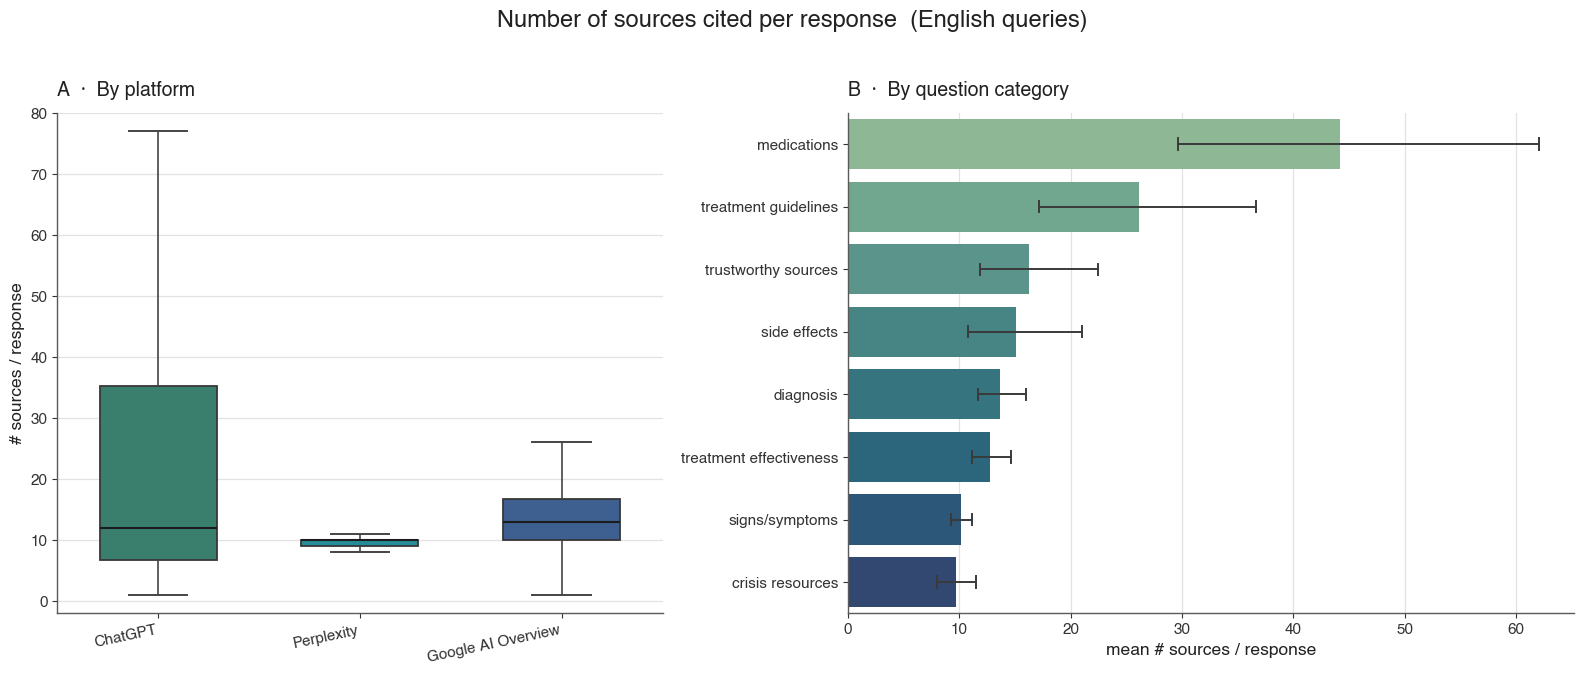

In [12]:
d = resp_en[resp_en.n_sources > 0]
cat_order = resp_en.groupby("topic_category")["n_sources"].mean().sort_values(ascending=False).index.tolist()
CAT_PAL = dict(zip(cat_order, sns.color_palette("crest", len(cat_order))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6.6), gridspec_kw={"width_ratios": [1, 1.2]})

sns.boxplot(data=d, x="provider_name", y="n_sources", order=PROVIDER_ORDER,
            hue="provider_name", hue_order=PROVIDER_ORDER, palette=PROVIDER_PAL,
            legend=False, showfliers=False, width=.58, linewidth=1.3,
            medianprops={"color": "#1c1c1c", "linewidth": 1.5},
            whiskerprops={"color": "#444", "linewidth": 1.2},
            capprops={"color": "#444", "linewidth": 1.4}, ax=axes[0])
axes[0].set_title("A  ·  By platform", loc="left", fontsize=14)
axes[0].set_xlabel(""); axes[0].set_ylabel("# sources / response")
axes[0].grid(axis="x", visible=False); axes[0].margins(y=0.04)
axes[0].tick_params(axis="x", rotation=12)
for lbl in axes[0].get_xticklabels(): lbl.set_ha("right")

# seed= makes the bootstrap CI deterministic
sns.barplot(data=resp_en, x="n_sources", y="topic_category", order=cat_order, orient="h",
            hue="topic_category", palette=CAT_PAL, legend=False,
            errorbar=("ci", 95), seed=SEED, err_kws={"color": "#3a3a3a", "linewidth": 1.4},
            capsize=.18, ax=axes[1])
axes[1].set_title("B  ·  By question category", loc="left", fontsize=14)
axes[1].set_xlabel("mean # sources / response"); axes[1].set_ylabel("")
axes[1].grid(axis="y", visible=False)

fig.suptitle("Number of sources cited per response  (English queries)",
             fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
save("figure1_citation_volume"); plt.show()

### Figure 2 — Distribution of cited domains (English)

Tiles are registrable domains, **except** that the NCBI/PubMed/PMC literature sites get their own
tile separate from the government `nih.gov` pages (NIMH, NIA, …). They classify as academic even
though they sit on a `.gov` domain, so splitting them keeps every tile type-homogeneous.

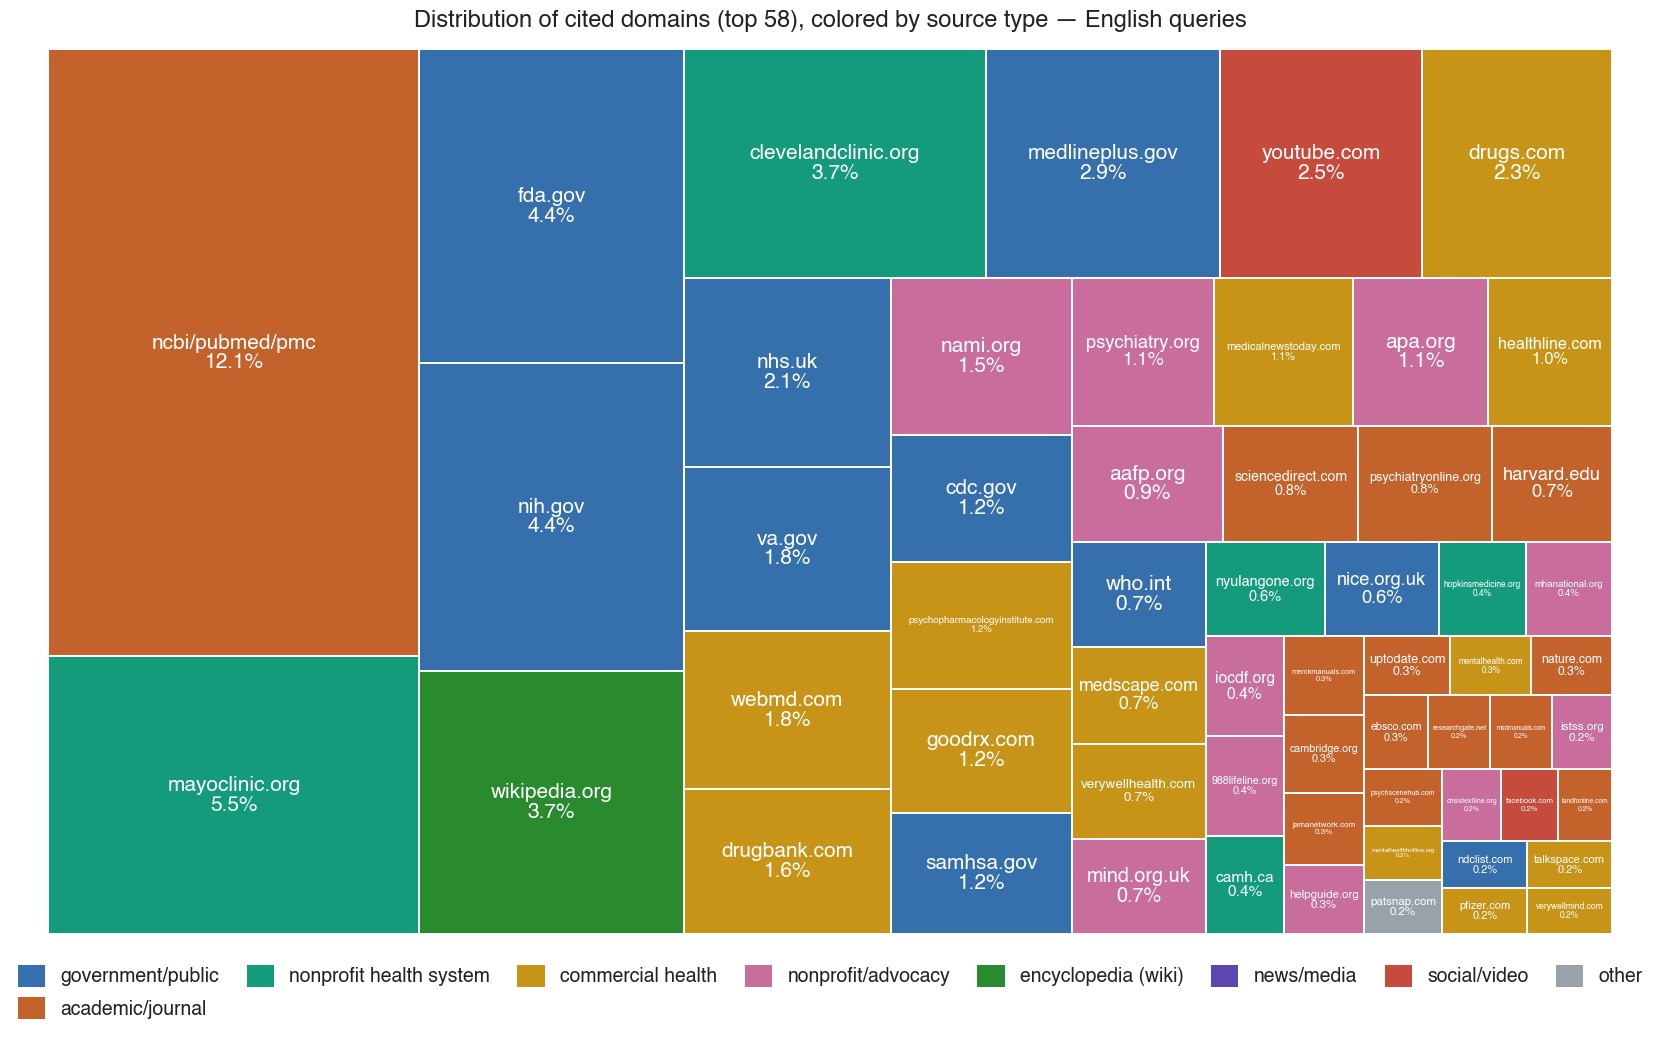

In [13]:
N = 58

# `site` was defined in section 2: registrable domain, except that the NCBI/PubMed/PMC
# literature hosts get their own tile so every tile is type-homogeneous.
dom = (src_en.groupby("site")
       .agg(n=("url", "size"), stype=("source_type", lambda s: s.mode().iloc[0]))
       .sort_values("n", ascending=False).head(N))
total = len(src_en)
sizes = dom["n"].to_numpy(dtype=float)
colors = [TYPE_PAL[t] for t in dom["stype"]]

W, H = 100.0, 62.0
rects = squarify.squarify(squarify.normalize_sizes(sizes, W, H), 0, 0, W, H)

fig, ax = plt.subplots(figsize=(16, 9.6))
for rect, col in zip(rects, colors):
    ax.add_patch(Rectangle((rect["x"], rect["y"]), rect["dx"], rect["dy"],
                           facecolor=col, edgecolor="white", linewidth=1.4))
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.invert_yaxis(); ax.axis("off")
ax.set_title(f"Distribution of cited domains (top {N}), colored by source type — English queries",
             fontsize=17, pad=16)
plt.tight_layout()
fig.canvas.draw()                      # finalize transforms before measuring text
renderer = fig.canvas.get_renderer()

def tile_px(rect):
    x0, y0 = ax.transData.transform((rect["x"], rect["y"]))
    x1, y1 = ax.transData.transform((rect["x"] + rect["dx"], rect["y"] + rect["dy"]))
    return abs(x1 - x0), abs(y1 - y0)

PAD, MIN_FS = 0.90, 4.3

def fits(t, maxw, maxh):
    bb = t.get_window_extent(renderer=renderer)
    return bb.width <= maxw and bb.height <= maxh

def place(rot, maxw, maxh, cx, cy, dm, pct, base_fs):
    """Try progressively shorter labels, shrinking the type until one fits."""
    for label in (f"{dm}\n{pct:.1f}%", dm, dm.split(".")[0]):
        fs = base_fs
        t = ax.text(cx, cy, label, ha="center", va="center", color="white",
                    fontweight="bold", fontsize=fs, linespacing=1.05, rotation=rot)
        for _ in range(16):
            if fits(t, maxw, maxh):
                return t
            fs *= 0.88
            if fs < MIN_FS:
                break
            t.set_fontsize(fs)
        t.remove()
    return None

for rect, dm, row in zip(rects, dom.index, dom.itertuples()):
    maxw, maxh = tile_px(rect)
    maxw *= PAD; maxh *= PAD
    pct = row.n / total * 100
    cx, cy = rect["x"] + rect["dx"] / 2, rect["y"] + rect["dy"] / 2
    base_fs = float(np.clip(np.sqrt(rect["dx"] * rect["dy"]) * 1.9, MIN_FS, 15))
    if place(0, maxw, maxh, cx, cy, dm, pct, base_fs) is None:
        place(90, maxw, maxh, cx, cy, dm, pct, base_fs)

ax.legend(handles=[Patch(facecolor=TYPE_PAL[t], label=t) for t in TYPE_ORDER],
          loc="upper center", bbox_to_anchor=(0.5, -0.015), ncol=8, fontsize=14,
          handlelength=1.4, handleheight=1.4, columnspacing=1.4)
save("figure2_domain_treemap"); plt.show()

### Figure 3 — Source-type composition by platform and question category (English)

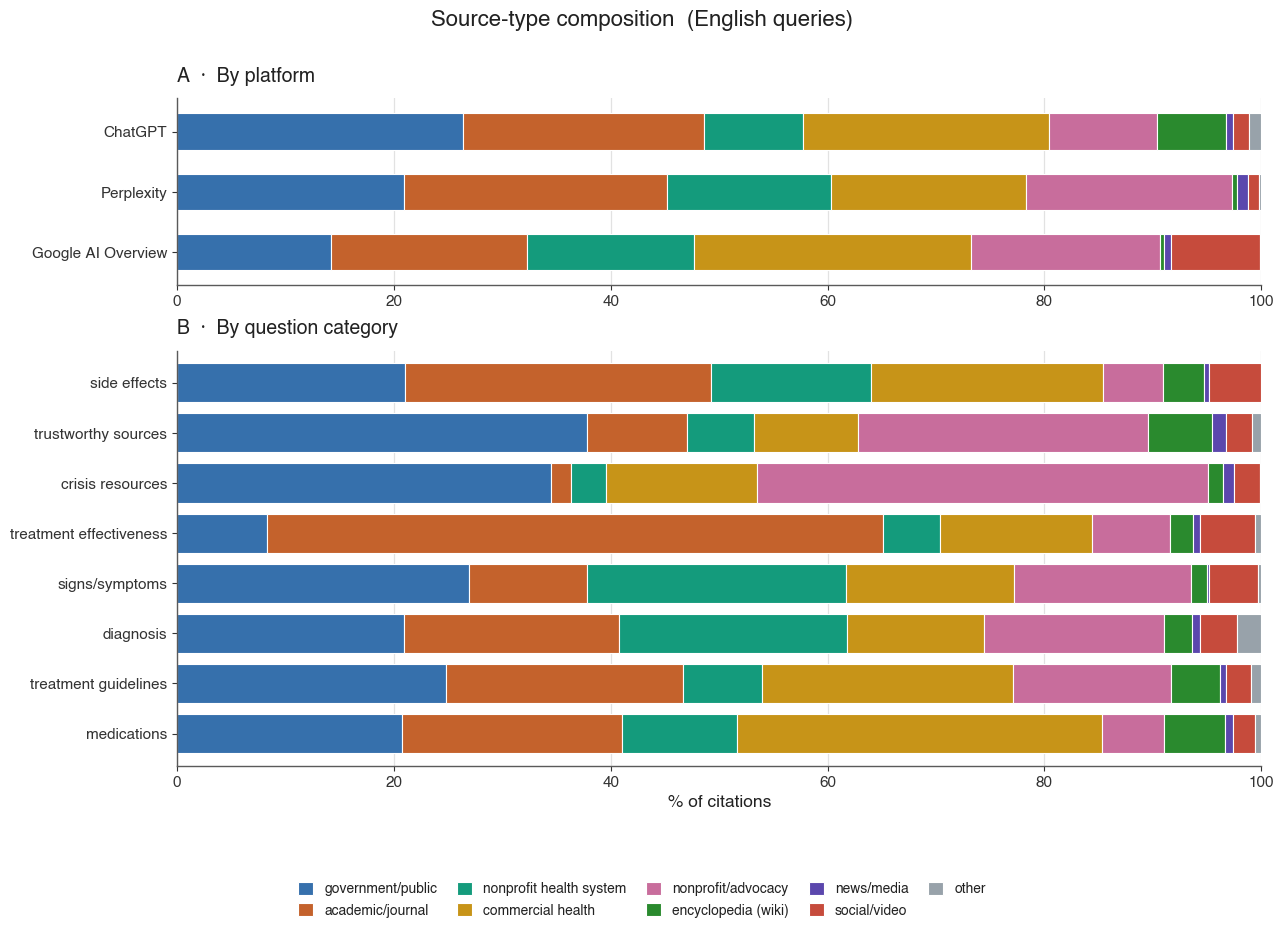

In [14]:
cat_order_s = src_en.groupby("topic_category").size().sort_values(ascending=False).index
ts_cat  = type_share(src_en, "topic_category").reindex(cat_order_s)
ts_plat = type_share(src_en, "provider_name").reindex(PROVIDER_ORDER[::-1])   # ChatGPT on top

fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={"height_ratios": [len(ts_plat) + 0.6, len(ts_cat)]})

ts_plat.plot(kind="barh", stacked=True, color=[TYPE_PAL[t] for t in ts_plat.columns],
             edgecolor="white", linewidth=0.8, width=.6, ax=axes[0], legend=False)
axes[0].set_title("A  ·  By platform", loc="left", fontsize=14)
axes[0].set_xlabel(""); axes[0].set_ylabel(""); axes[0].set_xlim(0, 100)
axes[0].grid(axis="y", visible=False)

ts_cat.plot(kind="barh", stacked=True, color=[TYPE_PAL[t] for t in ts_cat.columns],
            edgecolor="white", linewidth=0.8, width=.78, ax=axes[1], legend=False)
axes[1].set_title("B  ·  By question category", loc="left", fontsize=14)
axes[1].set_xlabel("% of citations"); axes[1].set_ylabel(""); axes[1].set_xlim(0, 100)
axes[1].grid(axis="y", visible=False)

handles, labels = axes[1].get_legend_handles_labels()
fig.suptitle("Source-type composition  (English queries)", fontsize=16, fontweight="bold", y=1.0)
plt.tight_layout()
# nine categories: 5 columns wraps to two even rows, and dropping the legend title keeps it
# clear of the "% of citations" axis label directly above
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 0.045),
           fontsize=10, frameon=False, handlelength=1.1, handleheight=1.1, columnspacing=1.4)
fig.subplots_adjust(bottom=0.16)
save("figure3_source_type_composition"); plt.show()

### Figure 4 — Effect of explicitly requesting sources (English)

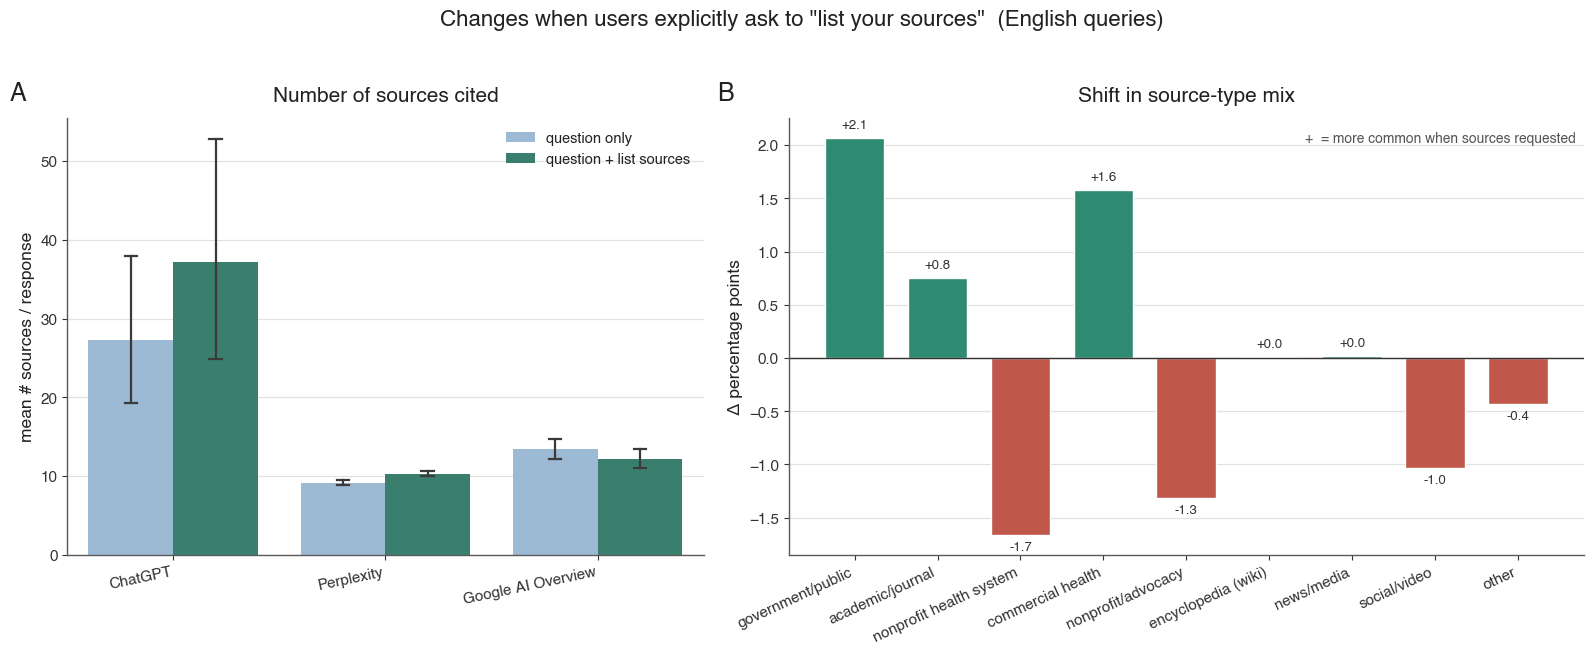

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.4), gridspec_kw={"width_ratios": [1, 1.25]})

sns.barplot(data=resp_en, x="provider_name", y="n_sources", order=PROVIDER_ORDER,
            hue="variant_label", hue_order=VARIANT_ORDER, palette=VARIANT_PAL,
            errorbar=("ci", 95), seed=SEED, capsize=.12,
            err_kws={"color": "#3a3a3a", "linewidth": 1.6}, ax=axes[0])
axes[0].set_title("Number of sources cited")
axes[0].set_xlabel(""); axes[0].set_ylabel("mean # sources / response")
axes[0].legend(title="", loc="upper right", fontsize=10.5)
axes[0].grid(axis="x", visible=False)
axes[0].tick_params(axis="x", rotation=12)
for lbl in axes[0].get_xticklabels(): lbl.set_ha("right")

ts = type_share(src_en, "variant_label").reindex(VARIANT_ORDER)
delta = (ts.loc["question + list sources"] - ts.loc["question only"]).reindex(TYPE_ORDER)
bars = axes[1].bar(range(len(delta)), delta.values,
                   color=[GREEN if v >= 0 else CORAL for v in delta.values],
                   edgecolor="white", width=.72)
axes[1].axhline(0, color="#333", lw=1)
axes[1].set_xticks(range(len(delta)))
axes[1].set_xticklabels(delta.index, rotation=25, ha="right")
axes[1].set_title("Shift in source-type mix")
axes[1].set_ylabel("Δ percentage points")
axes[1].grid(axis="x", visible=False)
for b, v in zip(bars, delta.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + (0.06 if v >= 0 else -0.06), f"{v:+.1f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=9.5, color="#333")
axes[1].text(0.99, 0.97, "+  = more common when sources requested", transform=axes[1].transAxes,
             ha="right", va="top", fontsize=10, style="italic", color="#555")

for ax, tag in zip(axes, "AB"):
    ax.text(-0.09, 1.04, tag, transform=ax.transAxes, fontsize=18, fontweight="bold")
fig.suptitle('Changes when users explicitly ask to "list your sources"  (English queries)',
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
save("figure4_source_request_effect"); plt.show()

### Figure 5 — Cross-lingual citation behavior

The only figure using all seven languages. Panel B decomposes language-appropriate routing into two
measures: citations on a **local-language ccTLD**, and native-language content served from a
**foreign or global domain** (`medlineplus.gov/spanish/`, `helsenorge.no/uk`). The second is what a
ccTLD-only measure misses, and for several languages it is the larger share.

language-signal detector matches the released column: True


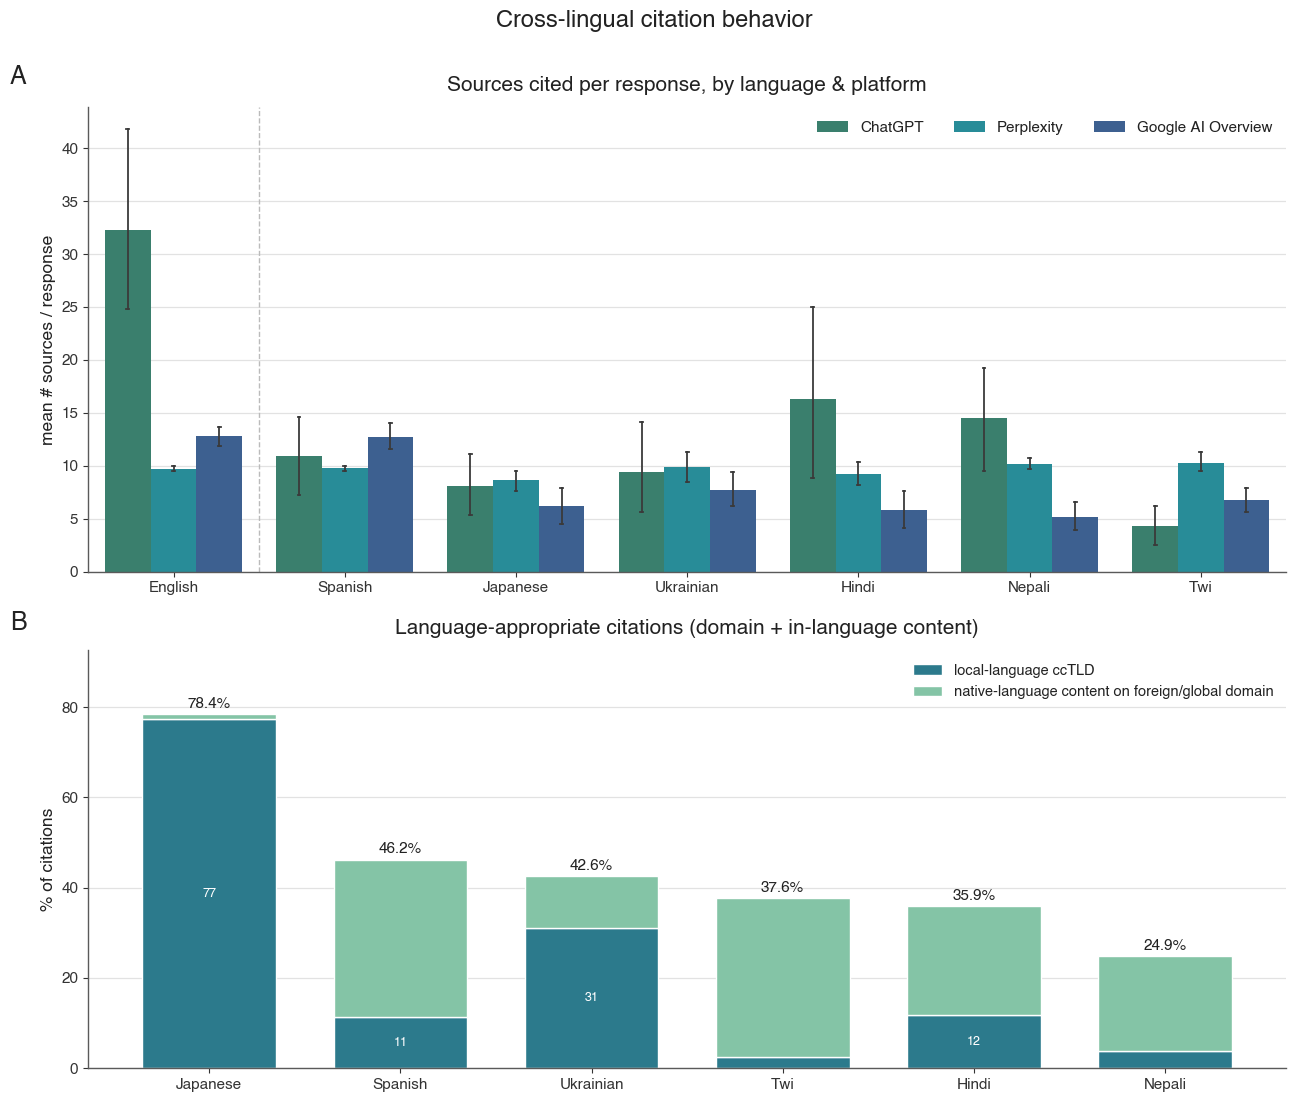

In [16]:
# `lang_signal` and `lang_appropriate` ship with the dataset; recomputed here so the detector is
# visible and auditable rather than opaque.
SIG = {
 "es": [r"/es(?:[-_/]|$)", r"/es-[a-z]{2}(?:[-_/]|$)", "espanol", "espa%c3%b1ol", "español",
        "spanish", r"-sp(?:[-_/.]|$)", r"[?&](?:lang|hl|setlang|locale|l)=es"],
 "uk": [r"/(?:uk|ua)(?:[-_/]|$)", "%d0", "%d1", "ukrainian"],
 "hi": [r"/(?:hi|hindi)(?:[-_/]|$)", "hindi", "%e0%a4", "%e0%a5", r"[?&](?:lang|hl|locale)=hi"],
 "ne": [r"/(?:ne|nepali|np)(?:[-_/]|$)", "nepali", "%e0%a4", "%e0%a5", r"[?&](?:lang|hl|locale)=ne"],
 "tw": [r"/(?:tw|twi)(?:[-_/]|$)", r"twi(?!tter|tch|st|light|n|rl|g|ce)", "akan"],
 "ja": [r"/(?:ja|jp|jpn|japanese)(?:[-_/]|$)", "japanese", "%e3%81", "%e3%82", "%e3%83",
        r"[?&](?:lang|hl|locale)=ja"],
}
recomputed_signal = pd.Series(
    [any(re.search(p, str(u).lower()) for p in SIG.get(l, []))
     for u, l in zip(src["url"], src["language"])], index=src.index)
print(f"language-signal detector matches the released column: "
      f"{bool((recomputed_signal == src['lang_signal']).all())}")

fig, axes = plt.subplots(2, 1, figsize=(13, 11), gridspec_kw={"height_ratios": [1, 0.9]})

sns.barplot(data=resp, x="language_name", y="n_sources", order=LANG7,
            hue="provider_name", hue_order=PROVIDER_ORDER, palette=PROVIDER_PAL,
            errorbar=("ci", 95), seed=SEED, capsize=.05,
            err_kws={"color": "#3a3a3a", "linewidth": 1.3}, ax=axes[0])
axes[0].axvline(0.5, color="#bbb", lw=1, ls="--")
axes[0].set_title("Sources cited per response, by language & platform")
axes[0].set_xlabel(""); axes[0].set_ylabel("mean # sources / response")
axes[0].grid(axis="x", visible=False)
axes[0].legend(title="", loc="upper right", fontsize=11, ncol=3)

ne_src = src[src.language != "en"]
local = ne_src.groupby("language_name")["is_local_source"].mean() * 100
comb  = ne_src.groupby("language_name")["lang_appropriate"].mean() * 100
order = comb.sort_values(ascending=False).index.tolist()
local = local.reindex(order)
abroad = comb.reindex(order) - local

axes[1].bar(order, local.values, color="#2C7A8C", edgecolor="white", width=.7,
            label="local-language ccTLD")
axes[1].bar(order, abroad.values, bottom=local.values, color="#84C4A6", edgecolor="white",
            width=.7, label="native-language content on foreign/global domain")
axes[1].set_title("Language-appropriate citations (domain + in-language content)")
axes[1].set_xlabel(""); axes[1].set_ylabel("% of citations")
axes[1].set_ylim(0, comb.reindex(order).max() * 1.18)
axes[1].grid(axis="x", visible=False)
axes[1].legend(loc="upper right", fontsize=10.5)
for i, lg in enumerate(order):
    axes[1].text(i, comb[lg] + 1.4, f"{comb[lg]:.1f}%", ha="center", fontsize=11,
                 fontweight="semibold")
    if local[lg] > 4:
        axes[1].text(i, local[lg] / 2, f"{local[lg]:.0f}", ha="center", va="center",
                     fontsize=9, color="white")

for ax, tag in zip(axes, "AB"):
    ax.text(-0.065, 1.05, tag, transform=ax.transAxes, fontsize=18, fontweight="bold")
fig.suptitle("Cross-lingual citation behavior", fontsize=17, fontweight="bold", y=1.0)
plt.tight_layout()
save("figure5_cross_lingual"); plt.show()